In [1]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter

# Single video analysis

In [2]:
# Extracting the video files from the directory
video_files = glob.glob("lab_4/Bead_004*.mpg")
print(f"Found video files: {video_files}")

Found video files: ['lab_4/Bead_004_075FR_02Collect.mpg', 'lab_4/Bead_004_130FR_01Collect.mpg', 'lab_4/Bead_004_120FR_03Collect.mpg', 'lab_4/Bead_004_135FR_02Collect.mpg', 'lab_4/Bead_004_145FR_01Collect.mpg', 'lab_4/Bead_004_151FR_02Collect.mpg', 'lab_4/Bead_004_130FR_03Collect.mpg', 'lab_4/Bead_004_120FR_01Collect.mpg', 'lab_4/Bead_004_145FR_03Collect.mpg', 'lab_4/Bead_004_125FR_02Collect.mpg', 'lab_4/Bead_004_050FR_02Collect.mpg', 'lab_4/Bead_004_025FR_02Collect.mpg', 'lab_4/Bead_004_151FR_03Collect.mpg', 'lab_4/Bead_004_050FR_01Collect.mpg', 'lab_4/Bead_004_025FR_01Collect.mpg', 'lab_4/Bead_004_120FR_02Collect.mpg', 'lab_4/Bead_004_075FR_03Collect.mpg', 'lab_4/Bead_004_125FR_01Collect.mpg', 'lab_4/Bead_004_135FR_03Collect.mpg', 'lab_4/Bead_004_050FR_03Collect.mpg', 'lab_4/Bead_004_151FR_01Collect.mpg', 'lab_4/Bead_004_025FR_03Collect.mpg', 'lab_4/Bead_004_075FR_01Collect.mpg', 'lab_4/Bead_004_130FR_02Collect.mpg', 'lab_4/Bead_004_145FR_02Collect.mpg', 'lab_4/Bead_004_125FR_03Collec

In [17]:
# Open up a video for test run.
cap = cv2.VideoCapture(video_files[0])  # Use the first video file found
print(f"Opened video: {video_files[0]}")

# Get video metadata
fps = cap.get(cv2.CAP_PROP_FPS)          # Should be 30 fps per the lab
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"FPS: {fps}, Frames: {total_frames}, Size: {width}x{height}")

# Extract frames
frames = []
while True:
    ret, frame = cap.read()   # ret=False when video ends
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    frames.append(gray)

cap.release()
frames = np.array(frames)  # shape: (N_frames, height, width)
print(f"Extracted {len(frames)} frames")

Opened video: lab_4/Bead_004_075FR_02Collect.mpg
FPS: 29.97002997002997, Frames: 211, Size: 720x480
Extracted 208 frames


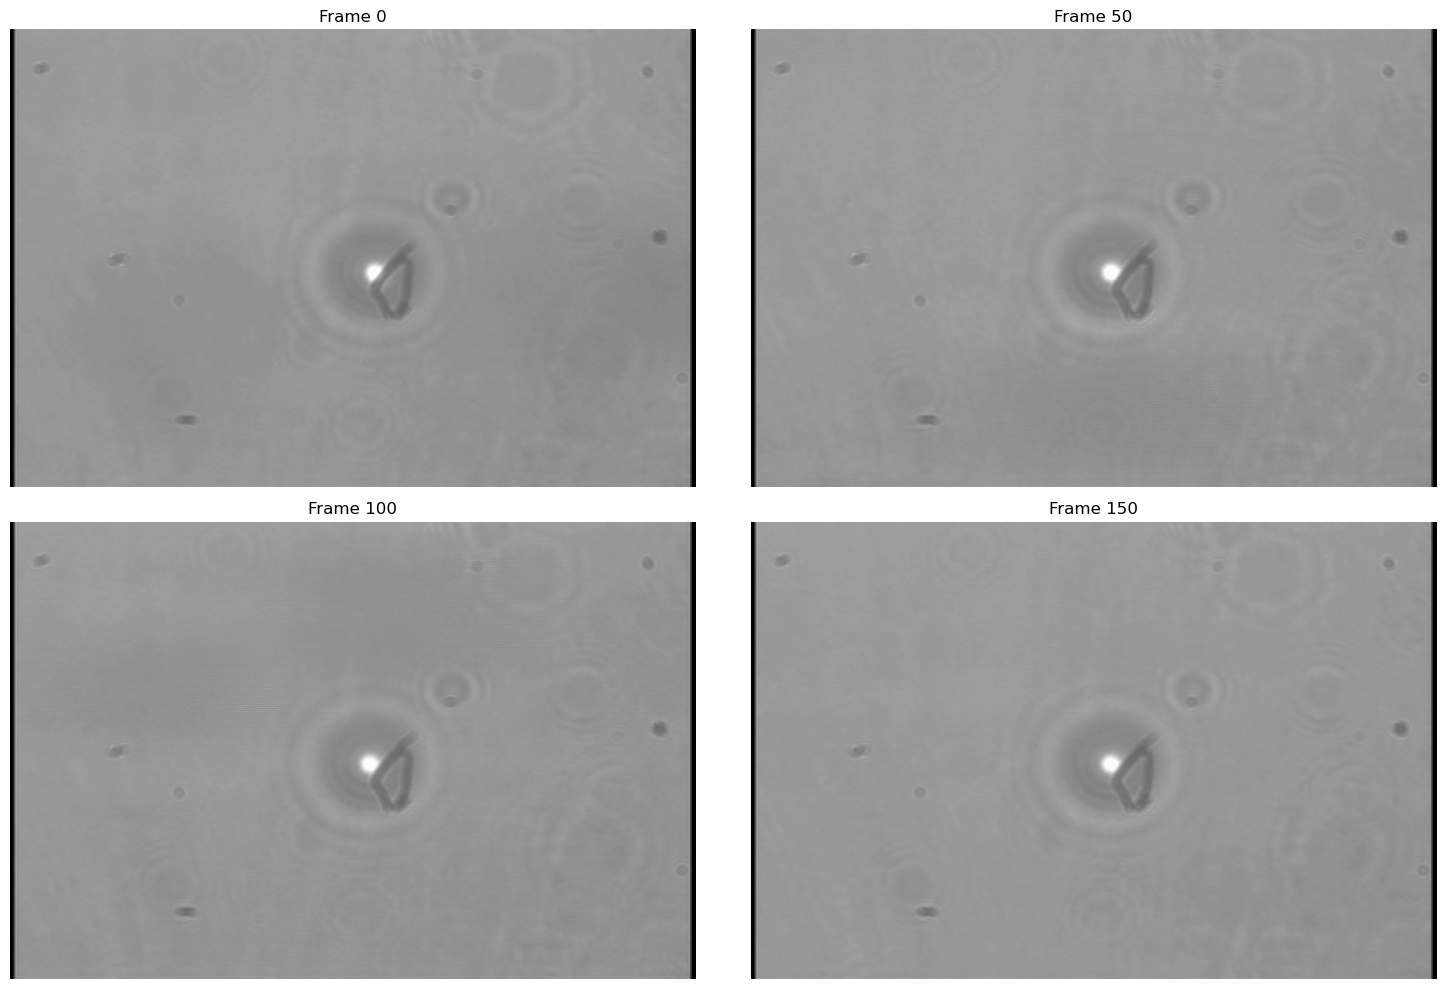

In [4]:
# Display multiple frames in a grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
frames_to_show = [0, 50, 100, 150]

for idx, ax in enumerate(axes.flat):
    if idx < len(frames_to_show):
        frame_num = frames_to_show[idx]
        ax.imshow(frames[frame_num], cmap='gray')
        ax.set_title(f"Frame {frame_num}")
    ax.axis('off')

plt.tight_layout()
plt.show()

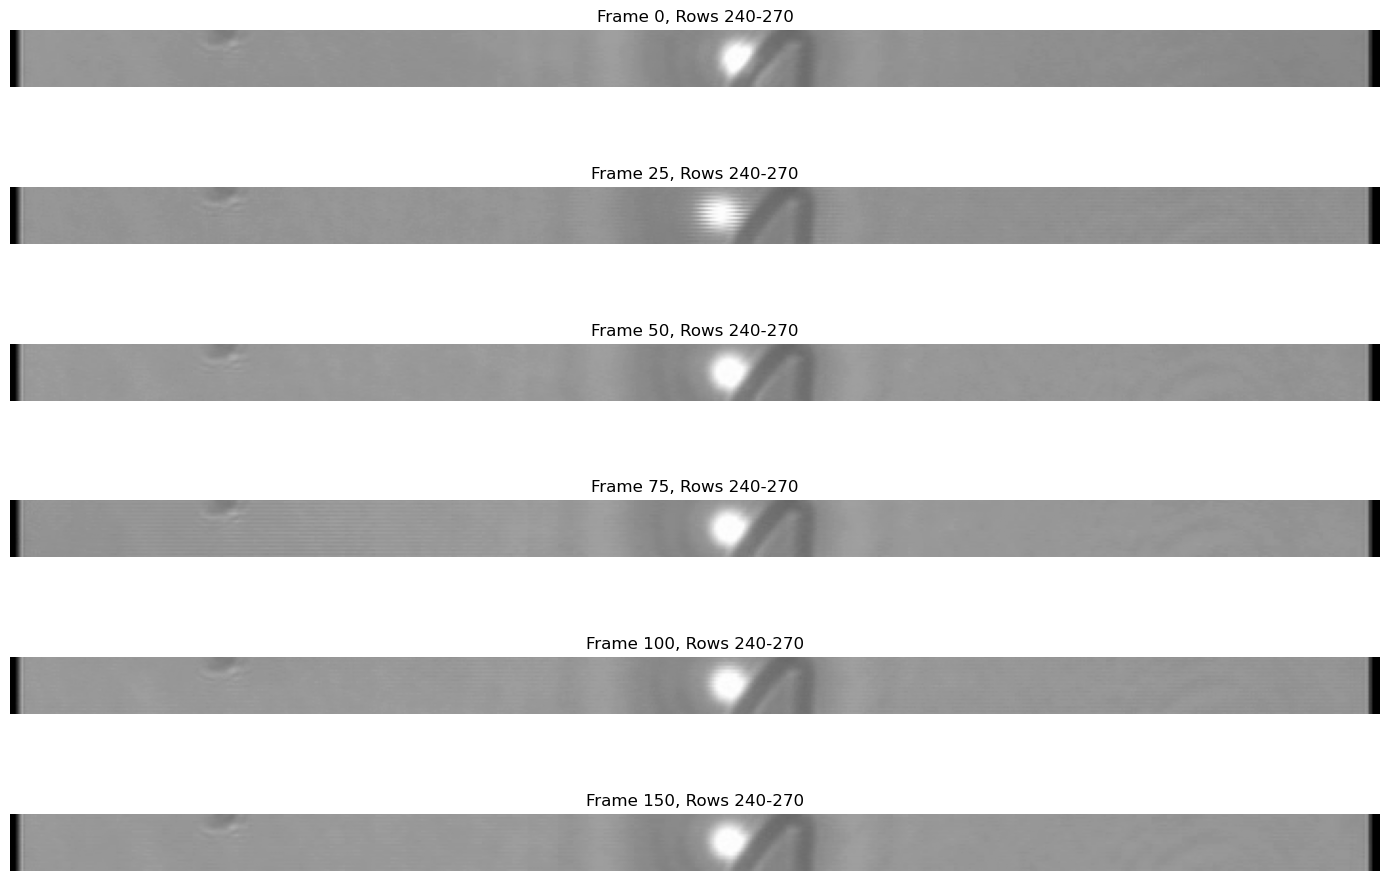

Selected region shape: (208, 30, 720)
Min intensity: 0, Max intensity: 255
Mean intensity: 146.96


In [5]:
# Select a range of rows from multiple frames and display them
start_row = 240    # Starting row index
end_row = 270      # Ending row index
frames_to_show = [0, 25, 50, 75, 100, 150]

# Extract the row range from all frames
frame_region = frames[:, start_row:end_row, :]

# Display selected frames with the row range
fig, axes = plt.subplots(6, 1, figsize=(14, 10))

for idx, ax in enumerate(axes.flat):
    if idx < len(frames_to_show):
        frame_num = frames_to_show[idx]
        ax.imshow(frame_region[frame_num], cmap='gray')
        ax.set_title(f"Frame {frame_num}, Rows {start_row}-{end_row}")
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Selected region shape: {frame_region.shape}")
print(f"Min intensity: {frame_region.min()}, Max intensity: {frame_region.max()}")
print(f"Mean intensity: {frame_region.mean():.2f}")

/var/folders/n6/t3xgmd094456ksq_31wfg64m0000gn/T/ipykernel_63256/737358867.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


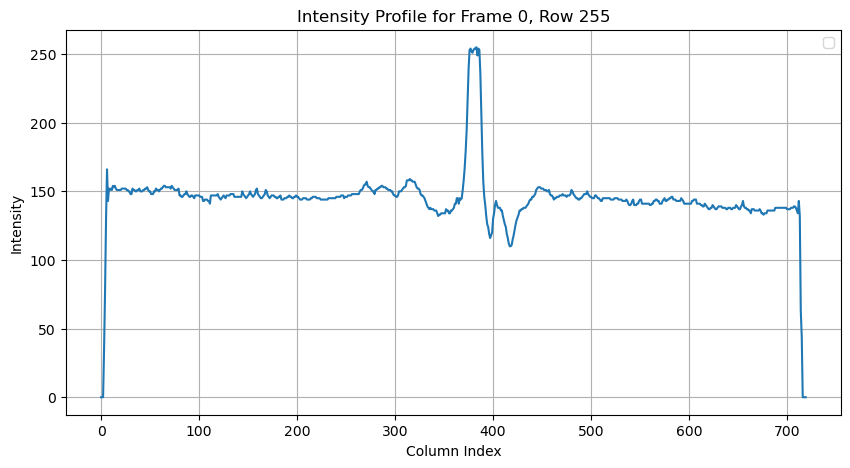

In [6]:
# For this one frame, plot the intensity along one row over column position
frame_region = frames[0, start_row:end_row, :]
row_index = 15  # Example row index
intensity_profile = frame_region[row_index, :]  # Get intensity values across columns for this row

plt.figure(figsize=(10, 5))
plt.plot(intensity_profile)
# Draw a vertical line at the column index of the maximum intensity
plt.legend()
plt.title(f"Intensity Profile for Frame 0, Row {start_row + row_index}")
plt.xlabel("Column Index")
plt.ylabel("Intensity")
plt.grid()
plt.show()

Background level: 140.00, Threshold: 197.50
Peak columns (above threshold): [374 375 376 377 378 379 380 381 382 383 384 385 386 387 388]
Estimated pixel size: 0.297 microns/pixel


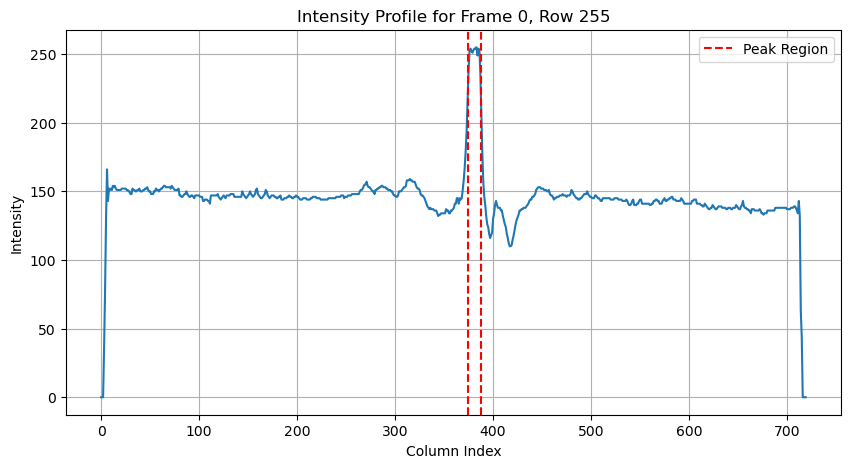

In [7]:
bead_diameter = 4.16 # microns, from lab manual

# Calibrate pixel scale using bead diameter
# Get intensity profile from frame 0
# Find the peak (bead) region - where intensity is significantly above background
background_level = np.percentile(intensity_profile, 25)  # Lower quartile as background
threshold = background_level + 0.5 * (np.max(intensity_profile) - background_level)
print(f"Background level: {background_level:.2f}, Threshold: {threshold:.2f}")

# Find columns where intensity exceeds threshold
peak_columns = np.where(intensity_profile > threshold)[0]
print(f"Peak columns (above threshold): {peak_columns}")

# Calculate pixel size in microns
pixel_size = bead_diameter / (peak_columns[-1] - peak_columns[0])
print(f"Estimated pixel size: {pixel_size:.3f} microns/pixel")

plt.figure(figsize=(10, 5))
plt.plot(intensity_profile)
# Draw two vertial lines at the column indices of the peak region
plt.axvline(x=peak_columns[0], color='r', linestyle='--', label='Peak Region')
plt.axvline(x=peak_columns[-1], color='r', linestyle='--')
plt.legend()
plt.title(f"Intensity Profile for Frame 0, Row {start_row + row_index}")
plt.xlabel("Column Index")
plt.ylabel("Intensity")
plt.grid()
plt.show()

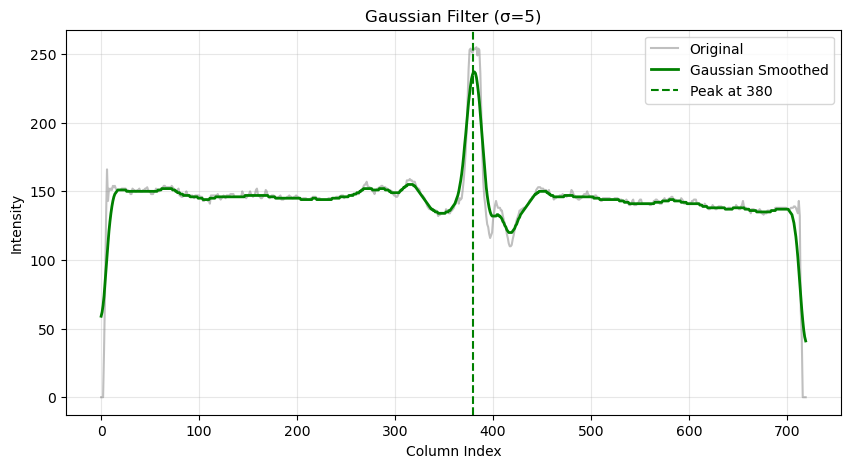

In [8]:
# Get one intensity profile from frame 0
frame_region_single = frames[0, start_row:end_row, :]
row_index = 15
intensity_profile = frame_region_single[row_index, :]

# Apply different smoothing filters
sigma = 5  # Standard deviation for Gaussian filter
smoothed_gaussian = gaussian_filter1d(intensity_profile, sigma=sigma)

# Find peaks
peak_gaussian = np.argmax(smoothed_gaussian)

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(intensity_profile, 'gray', label='Original', alpha=0.5)
plt.plot(smoothed_gaussian, 'g-', label='Gaussian Smoothed', linewidth=2)
plt.axvline(x=peak_gaussian, color='g', linestyle='--', label=f'Peak at {peak_gaussian}')
plt.title(f'Gaussian Filter (σ={sigma})')
plt.xlabel('Column Index')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

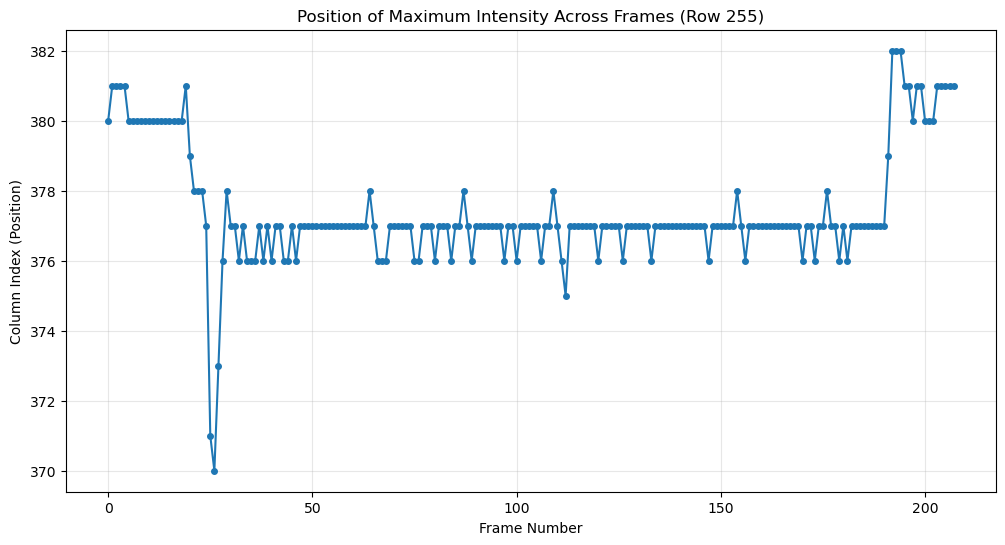

Mean position: 377.44 pixels
Std deviation: 1.67 pixels
Min position: 370, Max position: 382


In [9]:
# Analyze all frames and find max intensity position for each frame
frame_region = frames[:, start_row:end_row, :]
row_index = 15  # Example row index

# Track the column position of maximum intensity for each frame
max_intensity_positions = []

for frame_num in range(len(frame_region)):
    intensity_profile = frame_region[frame_num, row_index, :]
    smoothed_gaussian = gaussian_filter1d(intensity_profile, sigma=sigma)
    max_col_index = np.argmax(smoothed_gaussian)
    max_intensity_positions.append(max_col_index)

max_intensity_positions = np.array(max_intensity_positions)

# Plot: Frame number (x-axis) vs Max intensity position (y-axis)
plt.figure(figsize=(12, 6))
plt.plot(range(len(max_intensity_positions)), max_intensity_positions, marker='o', markersize=4)
plt.title(f"Position of Maximum Intensity Across Frames (Row {start_row + row_index})")
plt.xlabel("Frame Number")
plt.ylabel("Column Index (Position)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean position: {max_intensity_positions.mean():.2f} pixels")
print(f"Std deviation: {max_intensity_positions.std():.2f} pixels")
print(f"Min position: {max_intensity_positions.min()}, Max position: {max_intensity_positions.max()}")

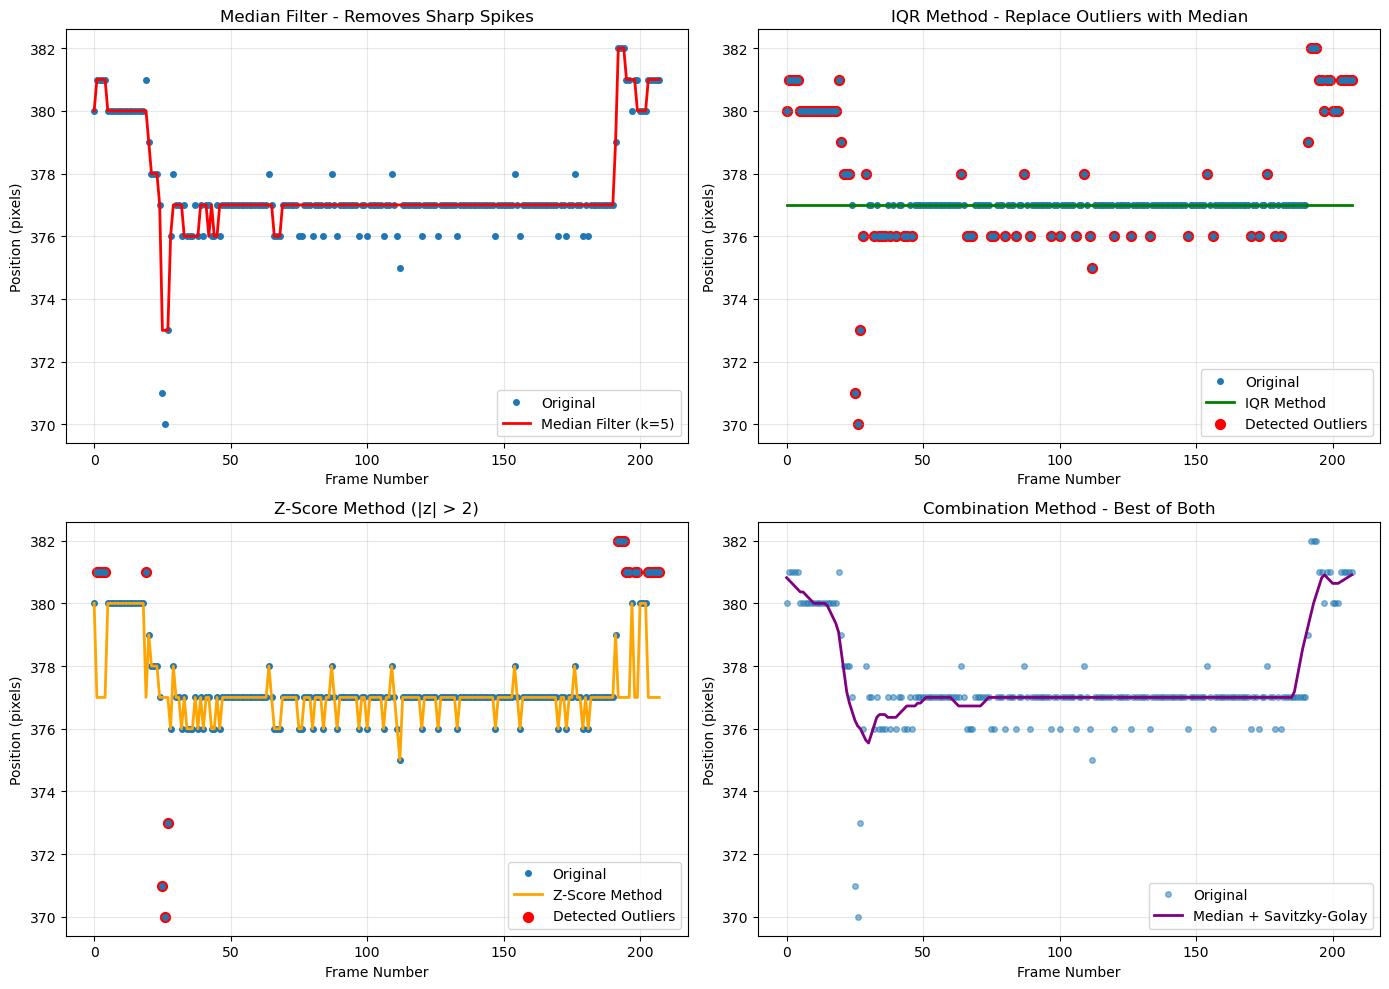

Outlier detection summary:
IQR method found 82 outliers
Z-score method found 20 outliers


In [10]:
# Different methods to remove outliers
from scipy.signal import medfilt

# Method 1: Median filter (removes spikes/outliers)
median_filtered = medfilt(max_intensity_positions, kernel_size=5)

# Method 2: IQR (Interquartile Range) method
Q1 = np.percentile(max_intensity_positions, 25)
Q3 = np.percentile(max_intensity_positions, 75)
IQR = Q3 - Q1
outlier_threshold = 1.5 * IQR
cleaned_iqr = max_intensity_positions.copy()
outlier_mask = (cleaned_iqr < Q1 - outlier_threshold) | (cleaned_iqr > Q3 + outlier_threshold)
cleaned_iqr[outlier_mask] = np.median(max_intensity_positions)

# Method 3: Z-score method (remove points > 2 std from mean)
z_scores = np.abs((max_intensity_positions - np.mean(max_intensity_positions)) / np.std(max_intensity_positions))
cleaned_zscore = max_intensity_positions.copy()
cleaned_zscore[z_scores > 2] = np.median(max_intensity_positions) # Replace outliers with median

# Method 4: Combination - Median filter + Savitzky-Golay
median_then_savgol = savgol_filter(medfilt(max_intensity_positions, kernel_size=5), window_length=11, polyorder=1)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(range(len(max_intensity_positions)), max_intensity_positions, 'o', markersize=4, label='Original')
axes[0, 0].plot(range(len(median_filtered)), median_filtered, 'r-', linewidth=2, label='Median Filter (k=5)')
axes[0, 0].set_title('Median Filter - Removes Sharp Spikes')
axes[0, 0].set_xlabel('Frame Number')
axes[0, 0].set_ylabel('Position (pixels)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(range(len(max_intensity_positions)), max_intensity_positions, 'o', markersize=4, label='Original')
axes[0, 1].plot(range(len(cleaned_iqr)), cleaned_iqr, 'g-', linewidth=2, label='IQR Method')
axes[0, 1].scatter(np.where(outlier_mask)[0], max_intensity_positions[outlier_mask], color='red', s=50, label='Detected Outliers')
axes[0, 1].set_title('IQR Method - Replace Outliers with Median')
axes[0, 1].set_xlabel('Frame Number')
axes[0, 1].set_ylabel('Position (pixels)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(range(len(max_intensity_positions)), max_intensity_positions, 'o', markersize=4, label='Original')
axes[1, 0].plot(range(len(cleaned_zscore)), cleaned_zscore, 'orange', linewidth=2, label='Z-Score Method')
axes[1, 0].scatter(np.where(z_scores > 2)[0], max_intensity_positions[z_scores > 2], color='red', s=50, label='Detected Outliers')
axes[1, 0].set_title('Z-Score Method (|z| > 2)')
axes[1, 0].set_xlabel('Frame Number')
axes[1, 0].set_ylabel('Position (pixels)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(range(len(max_intensity_positions)), max_intensity_positions, 'o', markersize=4, alpha=0.5, label='Original')
axes[1, 1].plot(range(len(median_then_savgol)), median_then_savgol, 'purple', linewidth=2, label='Median + Savitzky-Golay')
axes[1, 1].set_title('Combination Method - Best of Both')
axes[1, 1].set_xlabel('Frame Number')
axes[1, 1].set_ylabel('Position (pixels)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Outlier detection summary:")
print(f"IQR method found {np.sum(outlier_mask)} outliers")
print(f"Z-score method found {np.sum(z_scores > 2)} outliers")

In [11]:
# Calculate displacement using Z-score cleaned data
# Frame-to-frame displacement
displacements_cleaned = np.diff(cleaned_zscore)
frame_to_frame_displacement_cleaned = np.mean(np.abs(displacements_cleaned))

# Total displacement (overall change from start to end)
total_displacement_cleaned = cleaned_zscore[-1] - cleaned_zscore[0]

# Range of motion (max - min)
range_of_motion_cleaned = np.max(cleaned_zscore) - np.min(cleaned_zscore)

print("=== Z-Score Cleaned Data ===")
print(f"Average frame-to-frame displacement: {frame_to_frame_displacement_cleaned:.2f} pixels, " +\
      f"{frame_to_frame_displacement_cleaned * pixel_size:.2f} microns")
print(f"Total displacement (end - start): {total_displacement_cleaned:.2f} pixels, " +\
      f"{total_displacement_cleaned * pixel_size:.2f} microns")
print(f"Range of motion (max - min): {range_of_motion_cleaned:.2f} pixels, " +\
      f"{range_of_motion_cleaned * pixel_size:.2f} microns")
print(f"\nStart position: {cleaned_zscore[0]:.2f}")
print(f"End position: {cleaned_zscore[-1]:.2f}")
print(f"Min position: {np.min(cleaned_zscore):.2f}")
print(f"Max position: {np.max(cleaned_zscore):.2f}")

=== Z-Score Cleaned Data ===
Average frame-to-frame displacement: 0.45 pixels, 0.13 microns
Total displacement (end - start): -3.00 pixels, -0.89 microns
Range of motion (max - min): 5.00 pixels, 1.49 microns

Start position: 380.00
End position: 377.00
Min position: 375.00
Max position: 380.00


Velocity statistics (pixels/sec):
Mean: -0.43
Std: 2.88
Min: -15.37
Max: 7.18


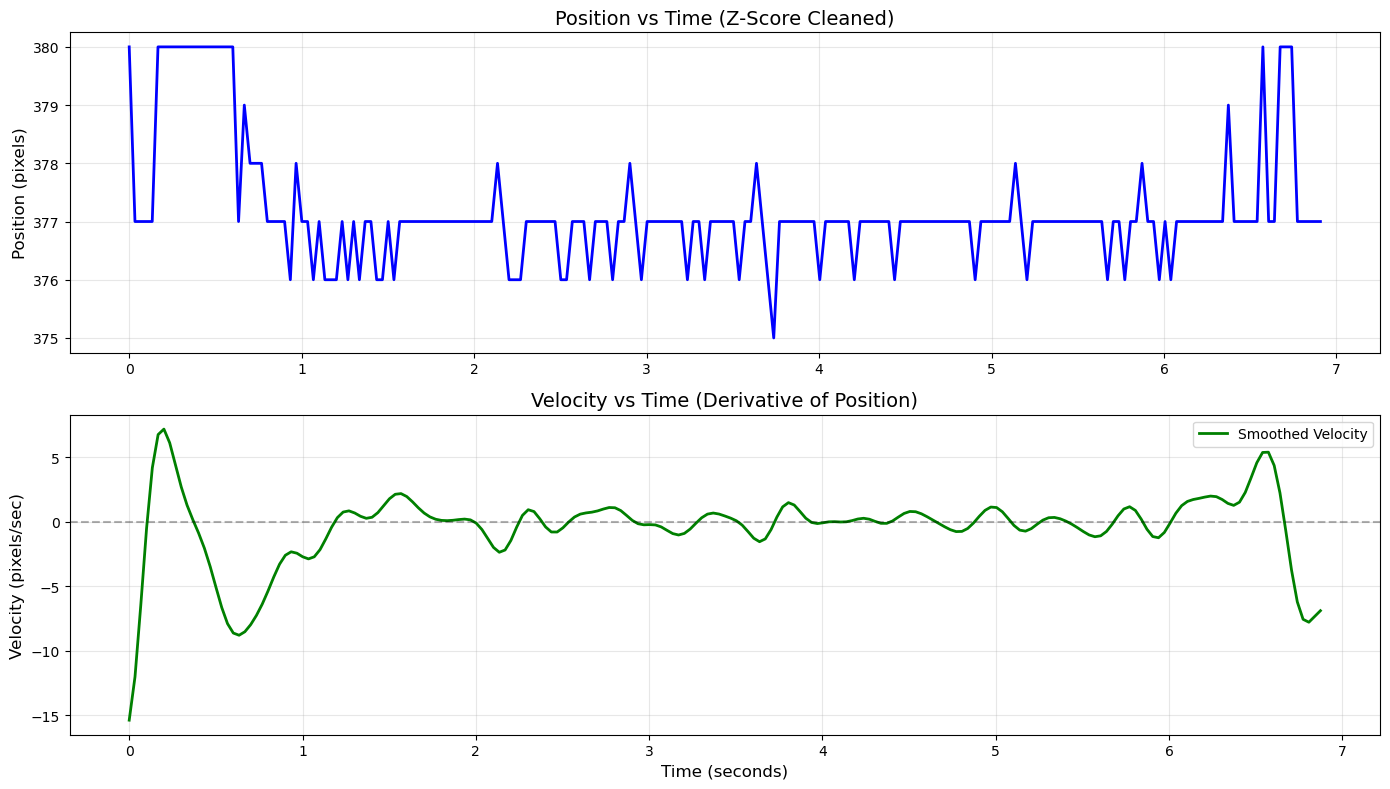

In [12]:
# Calculate velocity from position data
# velocity = dPosition/dTime

# Time between frames in seconds
time_per_frame = 1.0 / fps  # fps = 30 Hz

# Calculate velocity (in pixels per frame, then convert to pixels per second)
velocity_raw = np.diff(cleaned_zscore)  # pixels per frame
velocity_pixels_per_sec = velocity_raw / time_per_frame  # pixels per second

# Convert to microns per second
velocity_microns_per_sec = velocity_pixels_per_sec * pixel_size

# Smooth the velocity data to reduce noise (derivatives amplify noise)
velocity_smoothed = gaussian_filter1d(velocity_pixels_per_sec, sigma=3)

print(f"Velocity statistics (pixels/sec):")
print(f"Mean: {np.mean(velocity_smoothed):.2f}")
print(f"Std: {np.std(velocity_smoothed):.2f}")
print(f"Min: {np.min(velocity_smoothed):.2f}")
print(f"Max: {np.max(velocity_smoothed):.2f}")

# Plot position and velocity together
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Position plot
time_array = np.arange(len(cleaned_zscore)) * time_per_frame
ax1.plot(time_array, cleaned_zscore, 'b-', linewidth=2)
ax1.set_ylabel('Position (pixels)', fontsize=12)
ax1.set_title('Position vs Time (Z-Score Cleaned)', fontsize=14)
ax1.grid(True, alpha=0.3)

# Velocity plot
time_array_vel = np.arange(len(velocity_smoothed)) * time_per_frame
ax2.plot(time_array_vel, velocity_smoothed, 'g-', linewidth=2, label='Smoothed Velocity')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Velocity (pixels/sec)', fontsize=12)
ax2.set_title('Velocity vs Time (Derivative of Position)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

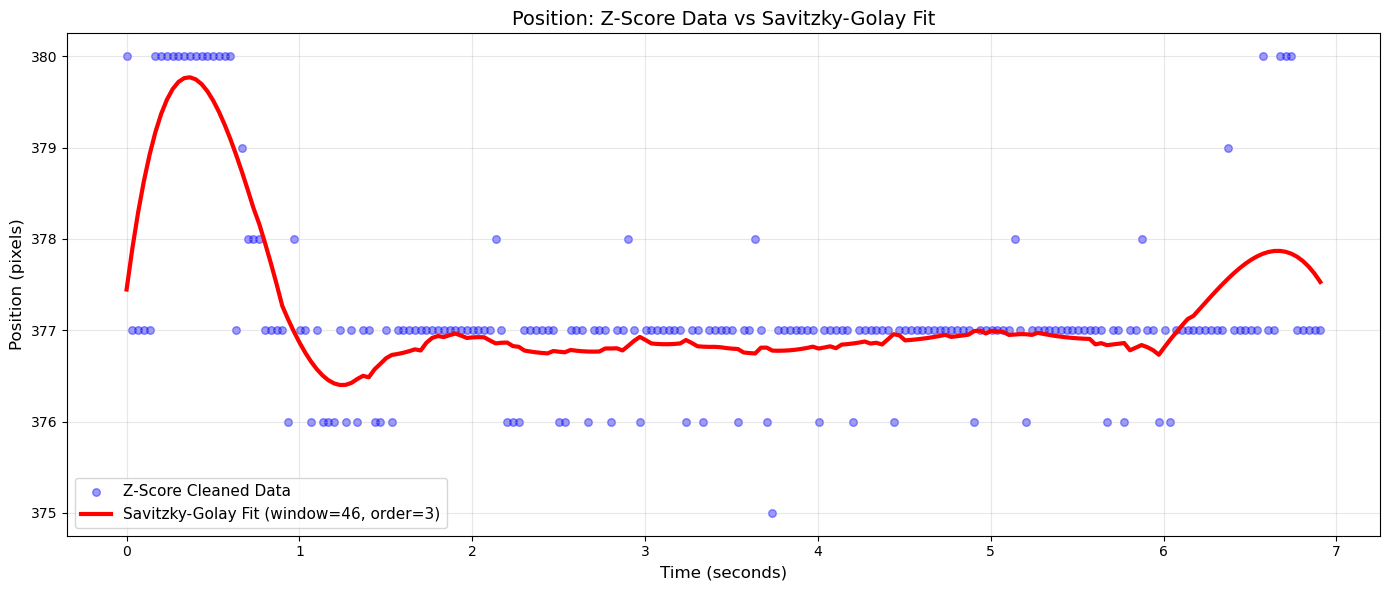

SAVITZKY-GOLAY FIT APPLIED
Window length: 46 frames (~1.53 seconds)
Polynomial order: 3
Data points: 208


In [13]:
# Apply Savitzky-Golay filter to cleaned position data
frame_numbers = np.arange(len(cleaned_zscore))

# Apply Savitzky-Golay filter
# window_length: number of points (must be odd). Larger = smoother
# polyorder: polynomial order. 3 is good for smooth derivatives
window_length = 46  # Points to use for local fitting (51 frames = ~1.7 sec)
polyorder = 3       # Polynomial order

savgol_position = savgol_filter(cleaned_zscore, window_length=window_length, polyorder=polyorder)

# Plot cleaned data vs Savitzky-Golay fit
fig, ax = plt.subplots(figsize=(14, 6))

time_array = frame_numbers * time_per_frame
ax.scatter(time_array, cleaned_zscore, alpha=0.4, s=30, label='Z-Score Cleaned Data', color='blue')
ax.plot(time_array, savgol_position, 'r-', linewidth=3, label=f'Savitzky-Golay Fit (window={window_length}, order={polyorder})')

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Position (pixels)', fontsize=12)
ax.set_title('Position: Z-Score Data vs Savitzky-Golay Fit', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 70)
print("SAVITZKY-GOLAY FIT APPLIED")
print("=" * 70)
print(f"Window length: {window_length} frames (~{window_length/fps:.2f} seconds)")
print(f"Polynomial order: {polyorder}")
print(f"Data points: {len(cleaned_zscore)}")
print("=" * 70)

VELOCITY STATISTICS (From Savitzky-Golay Derivative)
Velocity (pixels/sec):
  Mean: 0.05
  Min:  -6.65
  Max:  14.32

Velocity (microns/sec):
  Mean: 0.01
  Min:  -1.98
  Max:  4.26


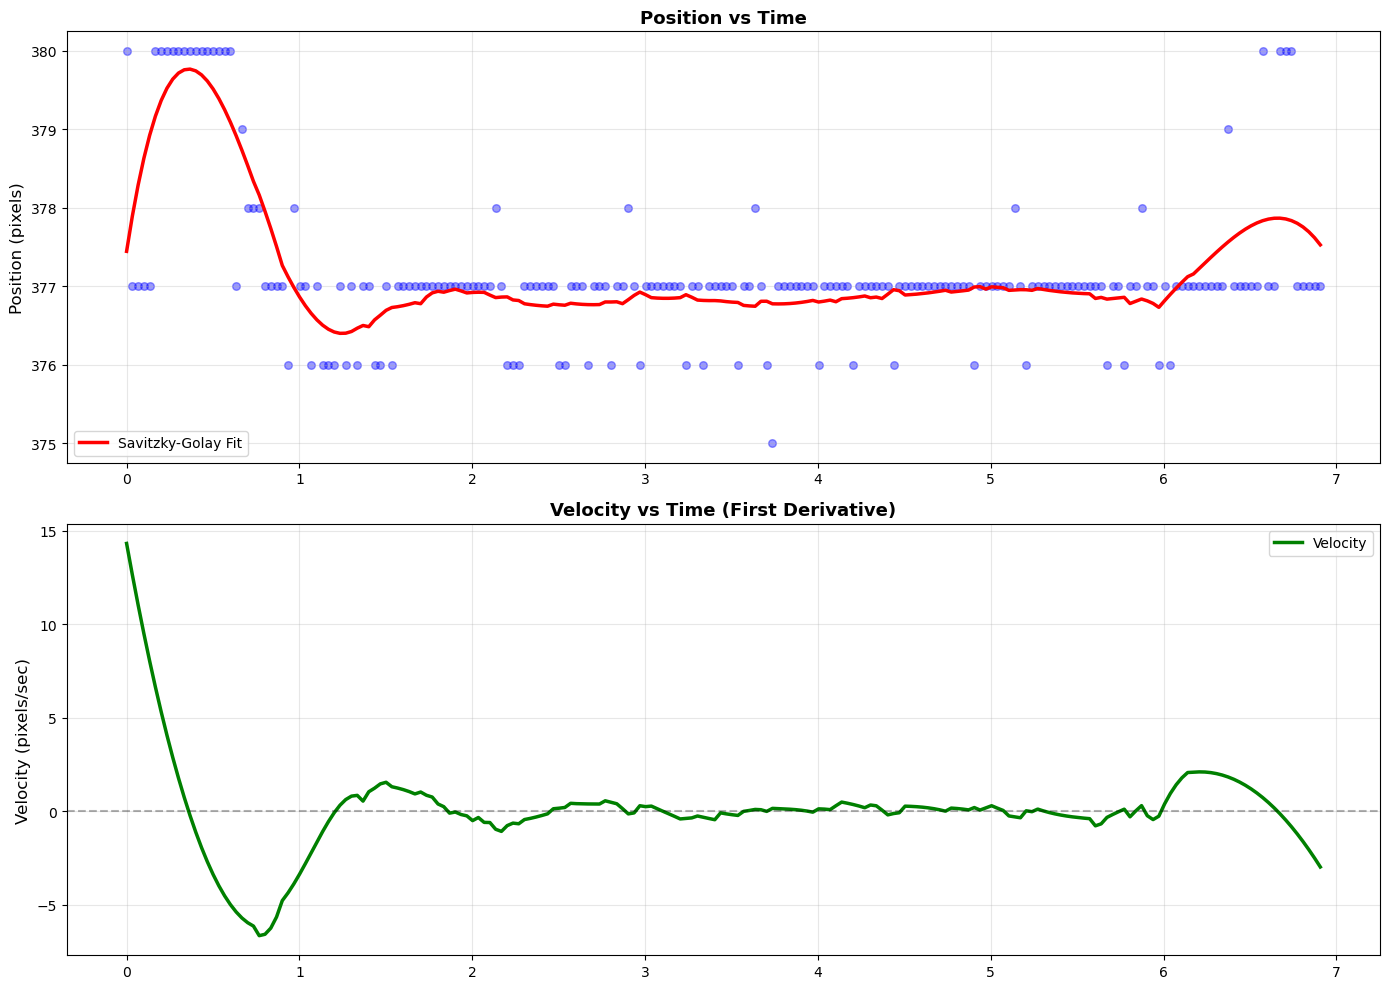

In [14]:
# Calculate velocity directly from Savitzky-Golay fit
# Since Savitzky-Golay preserves derivatives, we can use deriv() parameter

# Option 1: Use savgol_filter to get velocity directly (first derivative)
velocity_savgol_pixels = savgol_filter(cleaned_zscore, window_length=window_length, polyorder=polyorder, deriv=1)
# deriv=1 gives us dPosition/dFrame, so divide by time_per_frame
velocity_savgol_per_sec = velocity_savgol_pixels / time_per_frame

# Convert to microns/second
velocity_savgol_microns = velocity_savgol_per_sec * pixel_size

print("=" * 70)
print("VELOCITY STATISTICS (From Savitzky-Golay Derivative)")
print("=" * 70)
print(f"Velocity (pixels/sec):")
print(f"  Mean: {np.mean(velocity_savgol_per_sec):.2f}")
print(f"  Min:  {np.min(velocity_savgol_per_sec):.2f}")
print(f"  Max:  {np.max(velocity_savgol_per_sec):.2f}")
print(f"\nVelocity (microns/sec):")
print(f"  Mean: {np.mean(velocity_savgol_microns):.2f}")
print(f"  Min:  {np.min(velocity_savgol_microns):.2f}")
print(f"  Max:  {np.max(velocity_savgol_microns):.2f}")
print("=" * 70)

# Plot position, velocity, and acceleration
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Position
axes[0].scatter(time_array, cleaned_zscore, alpha=0.4, s=30, color='blue')
axes[0].plot(time_array, savgol_position, 'r-', linewidth=2.5, label='Savitzky-Golay Fit')
axes[0].set_ylabel('Position (pixels)', fontsize=12)
axes[0].set_title('Position vs Time', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Velocity
axes[1].plot(time_array, velocity_savgol_per_sec, 'g-', linewidth=2.5, label='Velocity')
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].set_ylabel('Velocity (pixels/sec)', fontsize=12)
axes[1].set_title('Velocity vs Time (First Derivative)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


Found 3 velocity peaks above threshold (1.08)
MOTION TIMING (From Savitzky-Golay Velocity)
Motion starts at:  0.000 sec (frame 0)
Motion stops at:   6.907 sec (frame 207)
Duration of motion: 6.907 sec (207 frames)


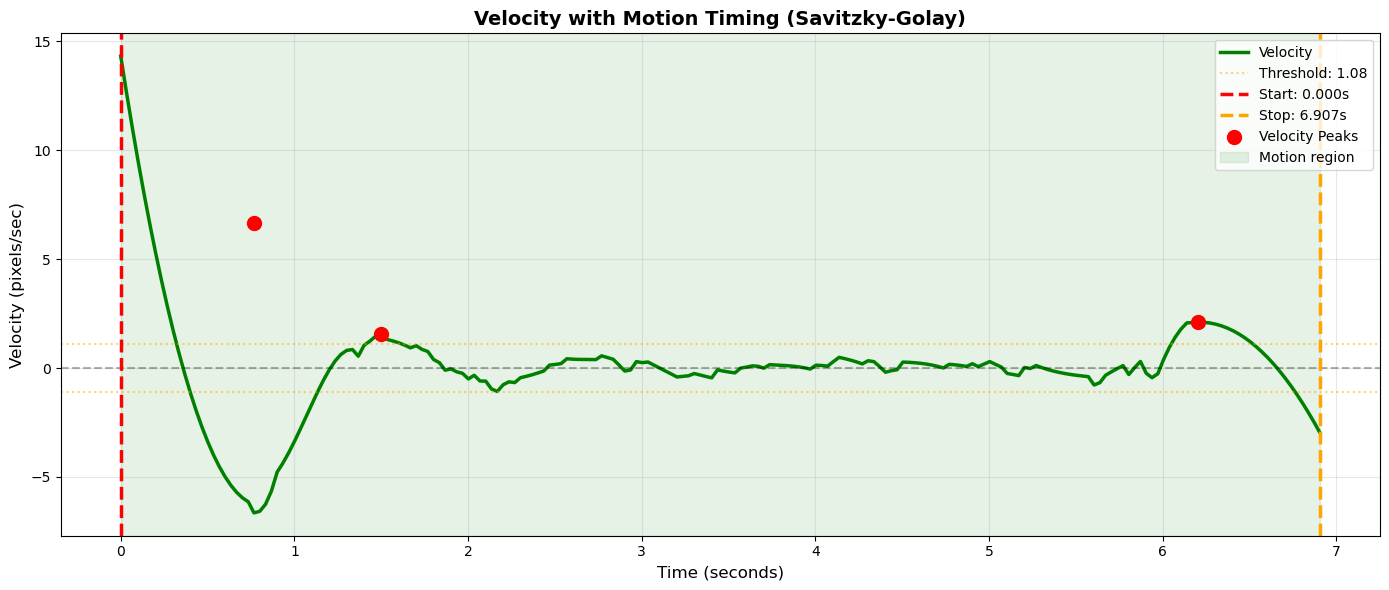

In [15]:
# Identify motion timing from velocity curve
from scipy.signal import find_peaks

# Find peaks in absolute velocity to identify start and stop of motion
abs_velocity = np.abs(velocity_savgol_per_sec)

# Threshold: peaks above 0.5 * std of velocity magnitude
velocity_threshold = np.std(abs_velocity) * 0.5
peaks, properties = find_peaks(abs_velocity, height=velocity_threshold, distance=10)

print(f"\nFound {len(peaks)} velocity peaks above threshold ({velocity_threshold:.2f})")

if len(peaks) >= 2:
    # First peak = start of motion (acceleration)
    start_peak_idx = peaks[0]
    # Last peak = stop of motion (deceleration)
    stop_peak_idx = peaks[-1]
    
    # Find edges: look for where velocity becomes very small
    # Start: go backward from start peak until velocity < 10% of threshold
    start_time_idx = 0
    for i in range(start_peak_idx, -1, -1):
        if abs_velocity[i] < velocity_threshold * 0.1:
            start_time_idx = i
            break
    
    # Stop: go forward from stop peak until velocity < 10% of threshold
    stop_time_idx = len(velocity_savgol_per_sec) - 1
    for i in range(stop_peak_idx, len(velocity_savgol_per_sec)):
        if abs_velocity[i] < velocity_threshold * 0.1:
            stop_time_idx = i
            break
    
    start_time_sec = start_time_idx * time_per_frame
    stop_time_sec = stop_time_idx * time_per_frame
    duration_sec = stop_time_sec - start_time_sec
    
    print("=" * 70)
    print("MOTION TIMING (From Savitzky-Golay Velocity)")
    print("=" * 70)
    print(f"Motion starts at:  {start_time_sec:.3f} sec (frame {start_time_idx})")
    print(f"Motion stops at:   {stop_time_sec:.3f} sec (frame {stop_time_idx})")
    print(f"Duration of motion: {duration_sec:.3f} sec ({stop_time_idx - start_time_idx} frames)")
    print("=" * 70)
    
    # Plot velocity with motion timing annotations
    fig, ax = plt.subplots(figsize=(14, 6))
    
    ax.plot(time_array, velocity_savgol_per_sec, 'g-', linewidth=2.5, label='Velocity')
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.axhline(y=velocity_threshold, color='orange', linestyle=':', alpha=0.5, label=f'Threshold: {velocity_threshold:.2f}')
    ax.axhline(y=-velocity_threshold, color='orange', linestyle=':', alpha=0.5)
    
    # Mark motion start and stop
    ax.axvline(x=start_time_sec, color='r', linestyle='--', linewidth=2.5, label=f'Start: {start_time_sec:.3f}s')
    ax.axvline(x=stop_time_sec, color='orange', linestyle='--', linewidth=2.5, label=f'Stop: {stop_time_sec:.3f}s')
    
    # Mark velocity peaks
    ax.scatter(peaks * time_per_frame, abs_velocity[peaks], color='red', s=100, zorder=5, label='Velocity Peaks')
    
    # Shade motion region
    ax.axvspan(start_time_sec, stop_time_sec, alpha=0.1, color='green', label='Motion region')
    
    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_ylabel('Velocity (pixels/sec)', fontsize=12)
    ax.set_title('Velocity with Motion Timing (Savitzky-Golay)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Warning: Could not identify enough peaks for motion timing")

Found 17 local minima

Top 5 minima (sorted by value):
  1. Index: 23, Value: -6.65 pixels/sec, Time: 0.767s
  2. Index: 65, Value: -1.07 pixels/sec, Time: 2.169s
  3. Index: 168, Value: -0.78 pixels/sec, Time: 5.606s
  4. Index: 60, Value: -0.50 pixels/sec, Time: 2.002s
  5. Index: 102, Value: -0.45 pixels/sec, Time: 3.403s

Selected minimum: Rank #1 (continuous)
Index: 23
Value: -6.65 pixels/sec
Time: 0.767 seconds


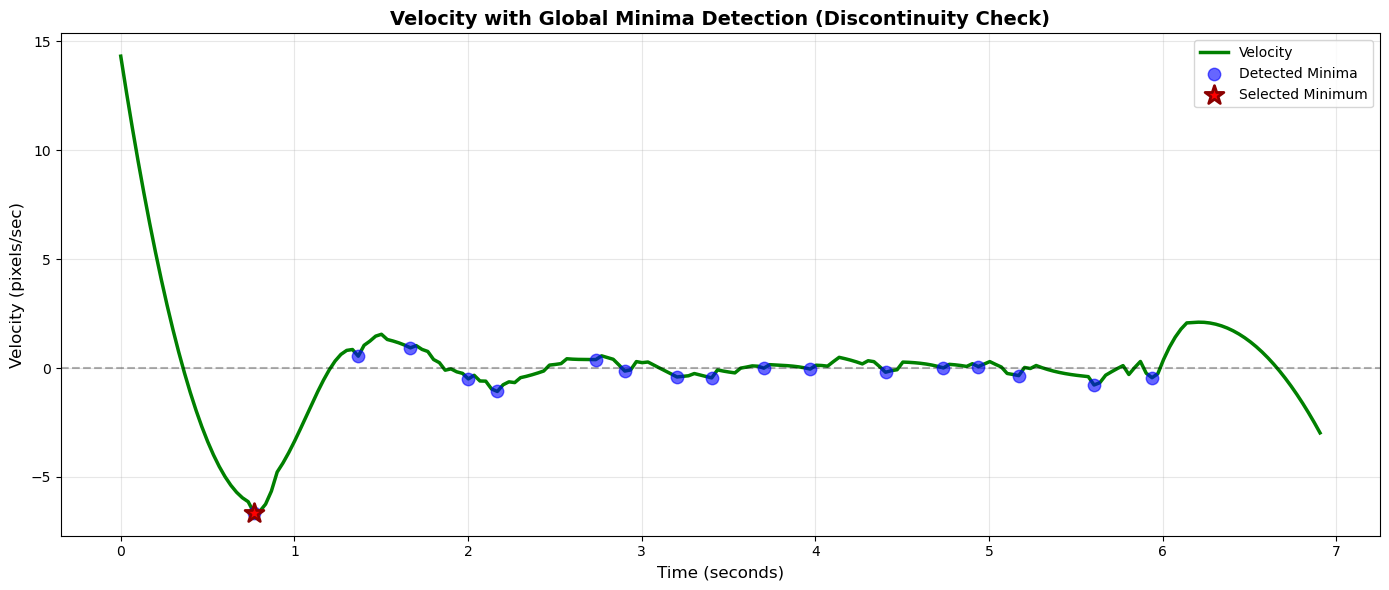

In [16]:
# Find global minima with discontinuity checking
from scipy.signal import find_peaks

# Find minima by finding peaks in the negative velocity curve
neg_velocity = -velocity_savgol_per_sec
minima_peaks, minima_props = find_peaks(neg_velocity, distance=5)  # distance to avoid cluttering

# Get the actual velocity values at minima positions
velocity_at_minima = velocity_savgol_per_sec[minima_peaks]

# Sort minima by value (most negative first) to get global and second global
sorted_indices = np.argsort(velocity_at_minima)
sorted_minima_indices = minima_peaks[sorted_indices]
sorted_minima_values = velocity_at_minima[sorted_indices]

print(f"Found {len(minima_peaks)} local minima")
print(f"\nTop 5 minima (sorted by value):")
for i in range(min(5, len(sorted_minima_values))):
    print(f"  {i+1}. Index: {sorted_minima_indices[i]}, Value: {sorted_minima_values[i]:.2f} pixels/sec, " +\
          f"Time: {sorted_minima_indices[i] * time_per_frame:.3f}s")

# Check discontinuity: a minimum is discontinuous if it has no neighbors
# OR if the data around it is sparse
def is_discontinuous(index, velocity_array, window=5):
    """
    Check if a point is discontinuous (isolated).
    A point is discontinuous if it has little to no variation around it
    or if the neighboring values are far from it.
    """
    if index - window < 0 or index + window >= len(velocity_array):
        return True  # At boundary
    
    left_region = velocity_array[max(0, index-window):index]
    right_region = velocity_array[index+1:min(len(velocity_array), index+window+1)]
    
    # If either neighbor region is empty or very small, it's discontinuous
    if len(left_region) == 0 or len(right_region) == 0:
        return True
    
    # Check if there's a sharp discontinuity (big gap from minimum)
    left_diff = np.min(np.abs(left_region - velocity_array[index]))
    right_diff = np.min(np.abs(right_region - velocity_array[index]))
    
    # If minimum gap is large (point is isolated), it's discontinuous
    threshold = 5.0  # pixels/sec - adjust as needed
    if min(left_diff, right_diff) > threshold:
        return True
    
    return False

# Find the best minimum (global or second global)
selected_minimum_idx = None
selected_minimum_value = None

for global_rank, sorted_idx in enumerate(sorted_minima_indices):
    if not is_discontinuous(sorted_idx, velocity_savgol_per_sec, window=5):
        selected_minimum_idx = sorted_idx
        selected_minimum_value = velocity_savgol_per_sec[sorted_idx]
        print(f"\n{'='*70}")
        print(f"Selected minimum: Rank #{global_rank+1} (continuous)")
        print(f"{'='*70}")
        print(f"Index: {selected_minimum_idx}")
        print(f"Value: {selected_minimum_value:.2f} pixels/sec")
        print(f"Time: {selected_minimum_idx * time_per_frame:.3f} seconds")
        print(f"{'='*70}")
        break
else:
    print("Warning: All minima are discontinuous!")
    if len(sorted_minima_indices) > 0:
        print("Using the global minimum anyway...")
        selected_minimum_idx = sorted_minima_indices[0]
        selected_minimum_value = sorted_minima_values[0]

# Plot all minima and highlight the selected one
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(time_array, velocity_savgol_per_sec, 'g-', linewidth=2.5, label='Velocity')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Plot all detected minima
ax.scatter(minima_peaks * time_per_frame, velocity_at_minima, 
           color='blue', s=80, alpha=0.6, label='Detected Minima', zorder=3)

# Highlight the selected minimum
if selected_minimum_idx is not None:
    ax.scatter(selected_minimum_idx * time_per_frame, selected_minimum_value, 
               color='red', s=200, marker='*', label='Selected Minimum', zorder=5, edgecolors='darkred', linewidth=2)

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Velocity (pixels/sec)', fontsize=12)
ax.set_title('Velocity with Global Minima Detection (Discontinuity Check)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()